# Sprint 1 EDA — 데이터 파이프라인 검증

**목적**: `data/processed/returns.parquet` 및 `features.parquet` 검증 + 보고서 섹션 2 기초 자료  
**실행 전**: `python -m src.data.collector` 로 파일이 생성되어 있어야 한다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RETURNS_PATH = Path("../data/processed/returns.parquet")
FEATURES_PATH = Path("../data/processed/features.parquet")

TICKERS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "VNQ", "069500", "114260"]

## 1. 파일 로드

In [2]:
returns = pd.read_parquet(RETURNS_PATH)
features = pd.read_parquet(FEATURES_PATH)

print("returns shape :", returns.shape)
print("features shape:", features.shape)

returns shape : (1423, 10)
features shape: (1390, 40)


## 2. 기본 정보 확인 (shape / columns / dtype / 날짜 범위)

In [3]:
print("=== returns ===")
print(f"index dtype : {returns.index.dtype}")
print(f"날짜 범위   : {returns.index[0].date()} ~ {returns.index[-1].date()}")
print(f"columns     : {list(returns.columns)}")
print()
print("=== features ===")
print(f"index dtype : {features.index.dtype}")
print(f"날짜 범위   : {features.index[0].date()} ~ {features.index[-1].date()}")
print(f"열 수       : {len(features.columns)}")
print(f"features 컬럼 (처음 8개): {list(features.columns[:8])}")

=== returns ===
index dtype : datetime64[ns]
날짜 범위   : 2020-01-03 ~ 2025-12-30
columns     : ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM', 'TLT', 'GLD', 'VNQ', '069500', '114260']

=== features ===
index dtype : datetime64[ns]
날짜 범위   : 2020-02-25 ~ 2025-12-30
열 수       : 40
features 컬럼 (처음 8개): ['SPY_return', 'QQQ_return', 'IWM_return', 'EFA_return', 'EEM_return', 'TLT_return', 'GLD_return', 'VNQ_return']


## 3. 결측치 확인

In [4]:
print("returns 결측치 합계  :", int(returns.isnull().sum().sum()))
print("features 결측치 합계 :", int(features.isnull().sum().sum()))

returns 결측치 합계  : 0
features 결측치 합계 : 0


## 4. returns 기술통계

In [5]:
returns.describe().round(4)

,SPY,QQQ,IWM,EFA,EEM,TLT,GLD,VNQ,069500,114260
count,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000,1423.0000
mean,0.0006,0.0008,0.0003,0.0003,0.0002,-0.0002,0.0007,0.0001,0.0006,0.0001
std,0.0134,0.0162,0.0174,0.0125,0.0141,0.0110,0.0106,0.0159,0.0136,0.0015
min,-0.1159,-0.1276,-0.1423,-0.1164,-0.1333,-0.0690,-0.0664,-0.1951,-0.0963,-0.0098
25%,-0.0049,-0.0068,-0.0089,-0.0055,-0.0063,-0.0070,-0.0048,-0.0067,-0.0070,-0.0006
50%,0.0011,0.0016,0.0005,0.0008,0.0005,0.0000,0.0009,0.0006,0.0010,0.0001
75%,0.0069,0.0092,0.0104,0.0068,0.0074,0.0062,0.0064,0.0076,0.0086,0.0008
max,0.0999,0.1134,0.0875,0.0813,0.0775,0.0725,0.0474,0.0861,0.0888,0.0109


## 5. 자산별 로그수익률 분포

C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2800711560.py:10: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(

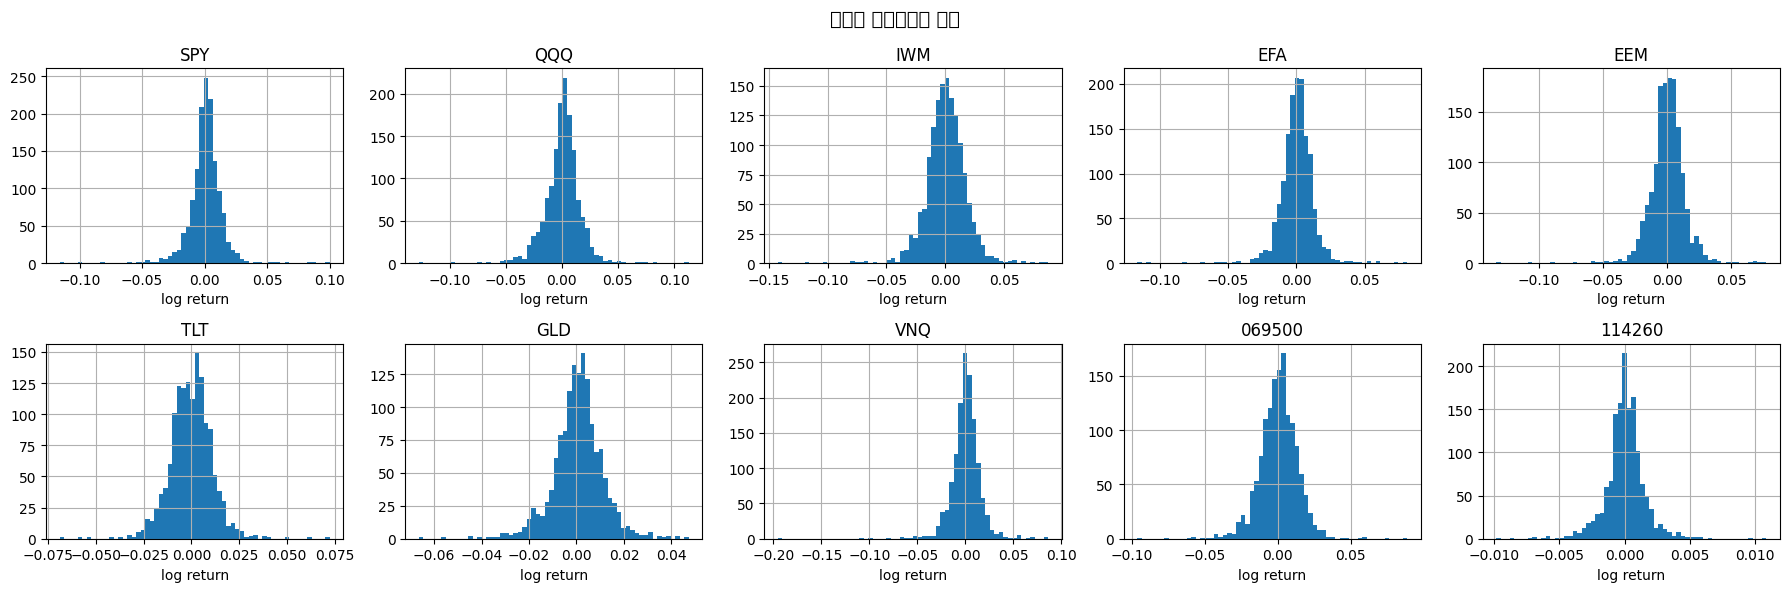

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, ticker in enumerate(TICKERS):
    returns[ticker].hist(bins=60, ax=axes[i])
    axes[i].set_title(ticker)
    axes[i].set_xlabel("log return")

fig.suptitle("자산별 로그수익률 분포", fontsize=14)
plt.tight_layout()
plt.show()

## 6. 상관관계 히트맵

C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\100216935.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaV

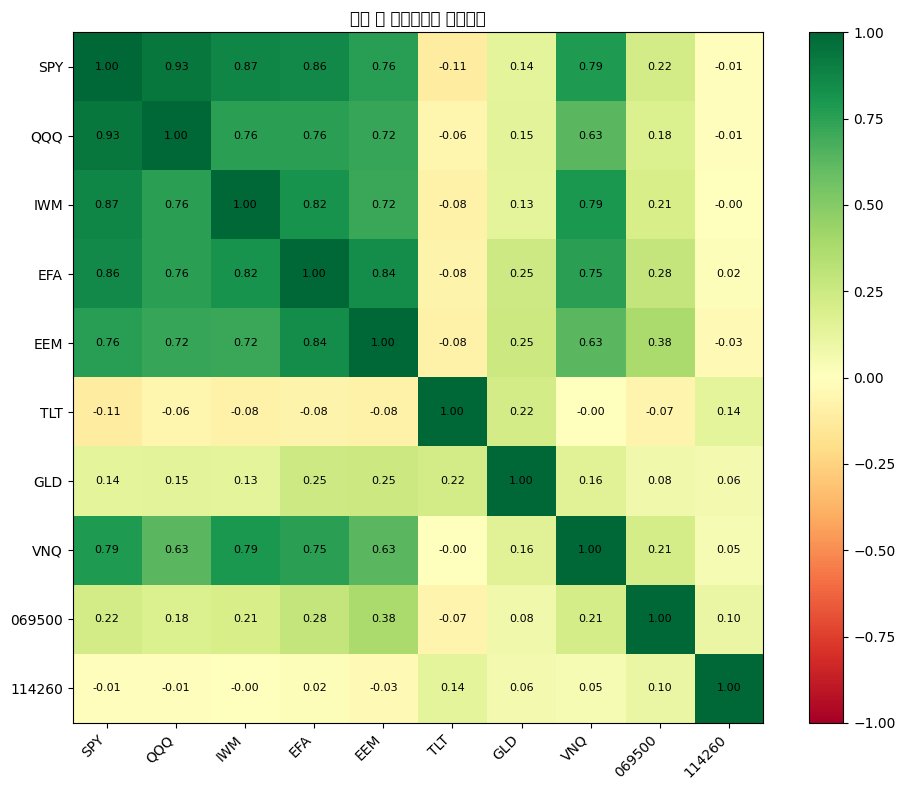

          SPY    QQQ    IWM    EFA    EEM    TLT    GLD    VNQ  069500  114260
SPY     1.000  0.935  0.868  0.859  0.761 -0.114  0.136  0.786   0.224  -0.010
QQQ     0.935  1.000  0.757  0.756  0.724 -0.060  0.145  0.632   0.185  -0.015
IWM     0.868  0.757  1.000  0.816  0.718 -0.080  0.135  0.794   0.207  -0.002
EFA     0.859  0.756  0.816  1.000  0.839 -0.078  0.248  0.751   0.283   0.018
EEM     0.761  0.724  0.718  0.839  1.000 -0.082  0.250  0.630   0.382  -0.032
TLT    -0.114 -0.060 -0.080 -0.078 -0.082  1.000  0.222 -0.000  -0.065   0.138
GLD     0.136  0.145  0.135  0.248  0.250  0.222  1.000  0.160   0.075   0.062
VNQ     0.786  0.632  0.794  0.751  0.630 -0.000  0.160  1.000   0.212   0.046
069500  0.224  0.185  0.207  0.283  0.382 -0.065  0.075  0.212   1.000   0.104
114260 -0.010 -0.015 -0.002  0.018 -0.032  0.138  0.062  0.046   0.104   1.000


In [8]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=45, ha="right")
ax.set_yticklabels(TICKERS)

for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("자산 간 로그수익률 상관관계")
plt.tight_layout()
plt.show()

print(corr.round(3))

## 7. 누적 수익률 그래프

C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 45572 (\N{HANGUL SYLLABLE NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\4001636851.py:12: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font

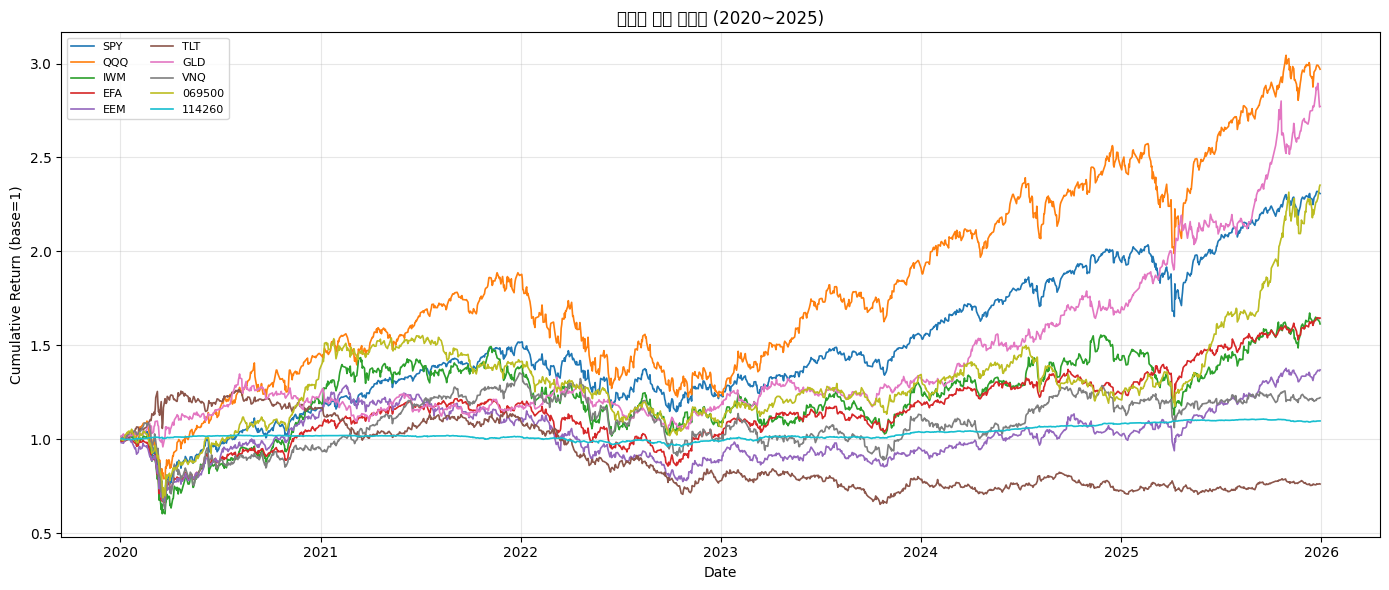

In [9]:
cumulative = returns.cumsum().apply(np.exp)  # log returns → price index

fig, ax = plt.subplots(figsize=(14, 6))
for ticker in TICKERS:
    ax.plot(cumulative.index, cumulative[ticker], label=ticker, linewidth=1.2)

ax.set_title("자산별 누적 수익률 (2020~2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return (base=1)")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. 자산별 변동성 비교 (연율화 표준편차)

C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2480850237.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(annual_vol_sorted.index, rotation=30, ha="right")
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2480850237.py:11: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2480850237.py:11: UserWarning: Glyph 49328 (\N{HANGUL SYLLABLE SAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2480850237.py:11: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykernel_5300\2480850237.py:11: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\82103\AppData\Local\Temp\ipykern

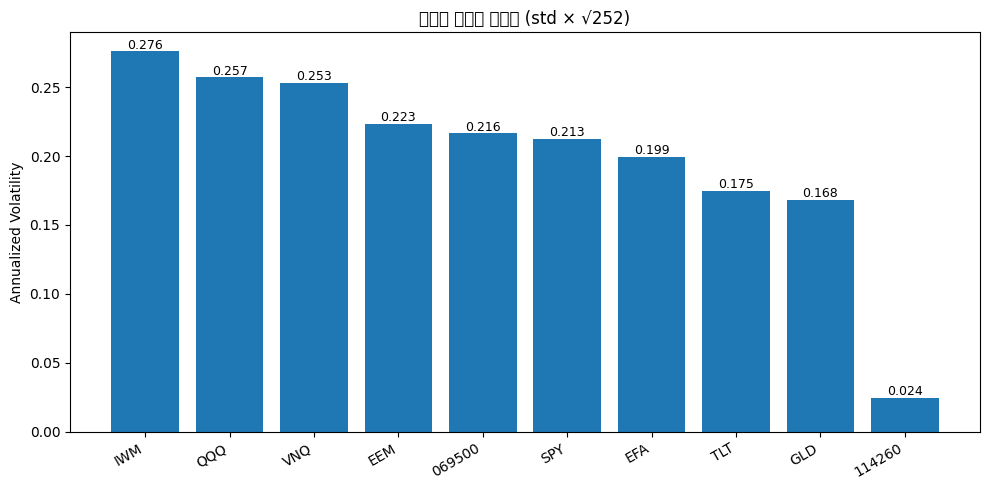

IWM       0.2759
QQQ       0.2570
VNQ       0.2530
EEM       0.2230
069500    0.2165
SPY       0.2125
EFA       0.1992
TLT       0.1750
GLD       0.1683
114260    0.0245
dtype: float64


In [10]:
annual_vol = returns.std() * np.sqrt(252)
annual_vol_sorted = annual_vol.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(annual_vol_sorted.index, annual_vol_sorted.values)
ax.set_title("자산별 연율화 변동성 (std × √252)")
ax.set_ylabel("Annualized Volatility")
ax.set_xticklabels(annual_vol_sorted.index, rotation=30, ha="right")
for i, v in enumerate(annual_vol_sorted.values):
    ax.text(i, v + 0.002, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(annual_vol_sorted.round(4))

## 9. features 컬럼 패턴 확인

In [11]:
return_cols = [c for c in features.columns if c.endswith("_return")]
rsi_cols    = [c for c in features.columns if c.endswith("_RSI")]
macd_cols   = [c for c in features.columns if c.endswith("_MACD")]
sig_cols    = [c for c in features.columns if c.endswith("_MACD_signal")]

print(f"_return 컬럼 수      : {len(return_cols)}")
print(f"_RSI 컬럼 수         : {len(rsi_cols)}")
print(f"_MACD 컬럼 수        : {len(macd_cols)}")
print(f"_MACD_signal 컬럼 수 : {len(sig_cols)}")
print(f"총 컬럼 수           : {len(features.columns)}")
print()
print("SPY 관련 컬럼 Z-score 통계:")
spy_cols = [c for c in features.columns if c.startswith("SPY")]
print(features[spy_cols].describe().round(3))

_return 컬럼 수      : 10
_RSI 컬럼 수         : 10
_MACD 컬럼 수        : 10
_MACD_signal 컬럼 수 : 10
총 컬럼 수           : 40

SPY 관련 컬럼 Z-score 통계:
       SPY_return   SPY_RSI  SPY_MACD  SPY_MACD_signal
count    1390.000  1390.000  1390.000         1390.000
mean        0.001    -0.099    -0.000            0.000
std         1.006     0.634     1.001            1.000
min        -8.699    -3.094    -7.088           -5.090
25%        -0.417    -0.469    -0.473           -0.461
50%         0.038    -0.089     0.031            0.019
75%         0.477     0.304     0.471            0.420
max         7.415     2.723     5.802            5.331
